# Task 2 (in progress) — ARIMA Forecasting for TSLA

Baseline classical statistical model for Task 2. Chronological train/test split (train:
2015–2024, test: 2025 onward), `auto_arima` for order selection, forecast evaluation via
MAE / RMSE / MAPE. LSTM comparison to follow before the final submission.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

sys.path.append(str(Path.cwd().parent))

plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load data and split chronologically

We forecast TSLA's **adjusted close price**. The split must preserve temporal order —
shuffling would leak future information into training. We train on 2015–2024 and hold
out 2025-01-01 through the end of the dataset (2026-06-29) as the test set.

Train: 2015-01-02 -> 2024-12-31 (2608 obs)
Test:  2025-01-01 -> 2026-06-29 (389 obs)


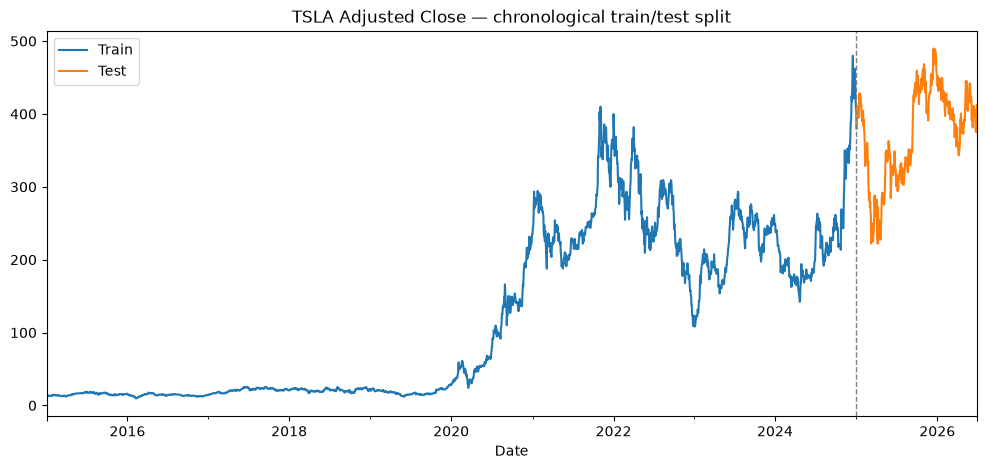

In [2]:
combined = pd.read_csv("../data/processed/combined_prices.csv", parse_dates=["Date"])
tsla = combined[combined["Asset"] == "TSLA"].set_index("Date").sort_index()["Adj Close"]

full_bdays = pd.date_range(tsla.index.min(), tsla.index.max(), freq="B")
tsla = tsla.reindex(full_bdays).ffill()
tsla.index.name = "Date"

TRAIN_END = "2024-12-31"
TEST_START = "2025-01-01"
train = tsla.loc[:TRAIN_END]
test = tsla.loc[TEST_START:]

print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} obs)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()} ({len(test)} obs)")

fig, ax = plt.subplots()
train.plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test")
ax.axvline(pd.Timestamp(TEST_START), color="gray", ls="--", lw=1)
ax.set_title("TSLA Adjusted Close — chronological train/test split")
ax.legend()
plt.show()

## 2. Order selection with `auto_arima`

Daily equity prices don't exhibit strong calendar seasonality (unlike e.g. retail sales),
so we search over non-seasonal ARIMA(p,d,q) orders. `auto_arima` handles differencing
selection (`d`) automatically via a stationarity test, consistent with the Task 1 finding
that the price level is non-stationary and requires differencing.

In [3]:
model = pm.auto_arima(
    train,
    start_p=0, start_q=0, max_p=5, max_q=5, max_d=2,
    seasonal=False,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore",
)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16873.591, Time=0.12 sec


 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.18 sec


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16873.127, Time=0.09 sec


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16877.541, Time=0.30 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.956 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2608
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8435.563
Date:                Sun, 05 Jul 2026   AIC                          16873.127
Time:                        22:27:04   BIC                          16878.993
Sample:                    01-02-2015   HQIC                         16875.252
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        37.8492      0.410     92.238      0.000      37.045

## 3. Forecast the test period and evaluate

Generate a static (non-updating) forecast over the full test horizon with 95% confidence
intervals, then score it against actuals with MAE, RMSE, and MAPE.

In [4]:
n_periods = len(test)
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True, alpha=0.05)
forecast = pd.Series(forecast, index=test.index)
lower = pd.Series(conf_int[:, 0], index=test.index)
upper = pd.Series(conf_int[:, 1], index=test.index)

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100

metrics = pd.DataFrame(
    {"ARIMA": {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape}}
).T
metrics

,MAE,RMSE,MAPE (%)
ARIMA,54.151953,70.196786,17.112171


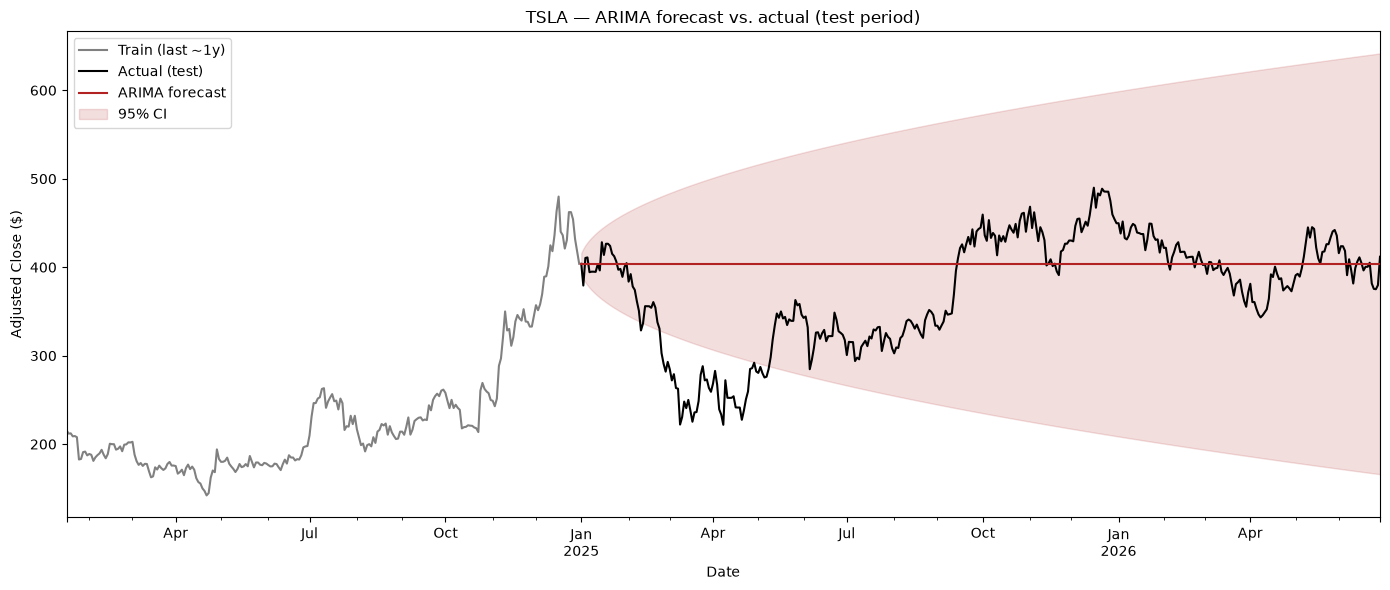

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
train.iloc[-250:].plot(ax=ax, label="Train (last ~1y)", color="gray")
test.plot(ax=ax, label="Actual (test)", color="black")
forecast.plot(ax=ax, label="ARIMA forecast", color="firebrick")
ax.fill_between(test.index, lower, upper, color="firebrick", alpha=0.15, label="95% CI")
ax.set_title("TSLA — ARIMA forecast vs. actual (test period)")
ax.set_ylabel("Adjusted Close ($)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Discussion (preliminary)

A static multi-period ARIMA forecast over an 18-month test horizon tends to converge
toward a long-run drift line, since ARIMA's point forecast beyond a few steps is driven
mostly by the fitted trend/constant rather than by newly observed data — consistent with
the Efficient Market Hypothesis view that little exploitable signal exists in past prices
alone. We expect the confidence interval to widen substantially over the horizon,
reflecting compounding uncertainty. This notebook establishes the ARIMA baseline; the
next step is an LSTM model on the same train/test split so both can be compared head to
head on MAE/RMSE/MAPE before final model selection in Task 2.